# Nonlinear Least Squares Benchmark Analysis ($n<m$ case)

In [1]:
from experiments import *
from visualization import *

import inspect
import optimization_project.problems.overdetermined as overdetermined_problems_module

In [2]:
problems = [
    cls() for name, cls in inspect.getmembers(overdetermined_problems_module, inspect.isclass)
    if name.endswith("Problem") and name != "Problem"
]

## Overall Results

In [3]:
df_results = benchmark_methods(problems)

 ---- Running problem: BoxBOD
 ---- Running problem: Chwirut1


/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))


 ---- Running problem: DanWood
 ---- Running problem: Eckerle4
 ---- Running problem: Lanczos3
 ---- Running problem: MGH17
 ---- Running problem: Misra1a


/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]


 ---- Running problem: Roszman1
 ---- Running problem: Thurber


In [4]:
df_results

,problem,difficulty,classification_model,structure,method,start_name,success,iterations,final_rss,parameter_error,relative_parameter_error,rss_error,relative_rss_error,gradient_norm
0,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,26,1.168009e+03,2.538628e-08,1.187328e-10,4.444655e-08,3.805327e-11,2.084644e-04
1,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 1,True,10,9.771500e+03,9.662656e+01,4.519270e-01,8.603491e+03,7.365947e+00,7.341368e-35
2,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 2,True,12,1.168009e+03,5.576125e-08,2.607980e-10,4.444746e-08,3.805404e-11,4.996470e-05
3,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 2,True,8,1.168009e+03,1.660473e-03,7.766111e-06,7.757208e-06,6.641395e-09,4.053286e-01
4,Chwirut1,Lower,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,20,2.384477e+03,5.216780e-09,2.736055e-08,9.350970e-09,3.921602e-12,5.336562e-03
5,Chwirut1,Lower,Exponential,Overdetermined,LM-lm,NIST Start 1,True,9,2.384477e+03,6.537914e-06,3.428952e-05,1.145087e-06,4.802258e-10,4.790192e+00
6,Chwirut1,Lower,Exponential,Overdetermined,ModifiedGN,NIST Start 2,True,15,2.384477e+03,4.751358e-08,2.491954e-07,9.415544e-09,3.948683e-12,4.365956e-02
7,Chwirut1,Lower,Exponential,Overdetermined,LM-lm,NIST Start 2,True,5,2.384477e+03,2.353497e-06,1.234343e-05,7.749459e-07,3.249961e-10,9.618043e+00
8,DanWood,Lower,Miscellaneous,Overdetermined,ModifiedGN,NIST Start 1,True,10,4.317308e-03,9.598747e-09,2.438566e-09,8.948571e-15,2.072720e-12,4.346728e-09
9,DanWood,Lower,Miscellaneous,Overdetermined,LM-lm,NIST Start 1,True,6,4.317308e-03,2.480603e-08,6.301983e-09,8.687495e-15,2.012248e-12,9.487881e-09


---

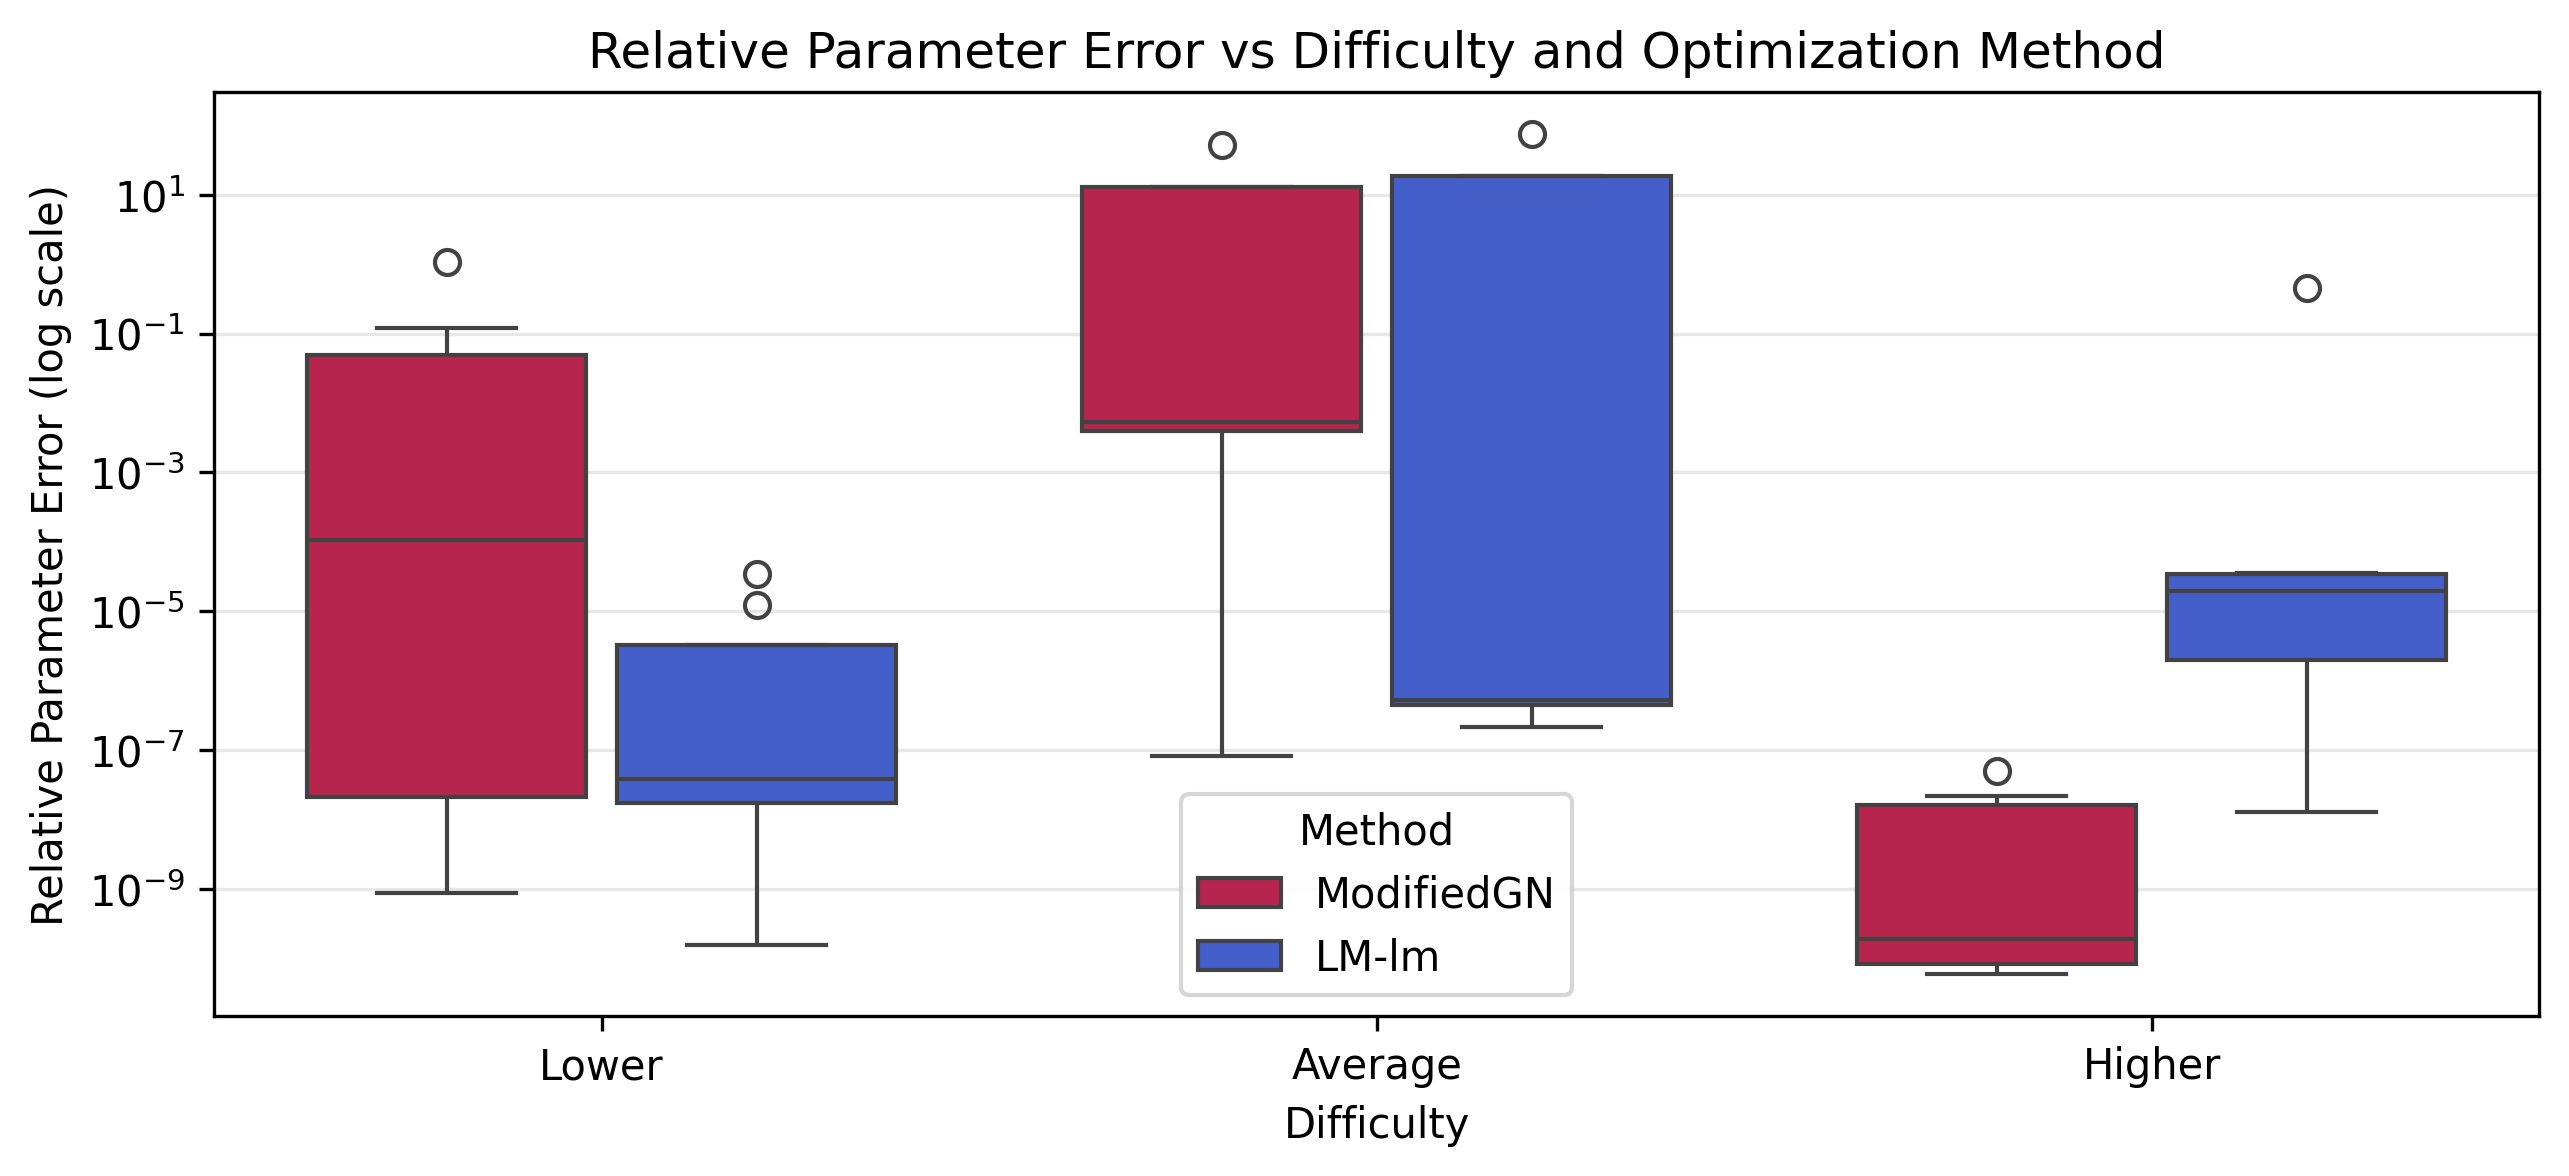

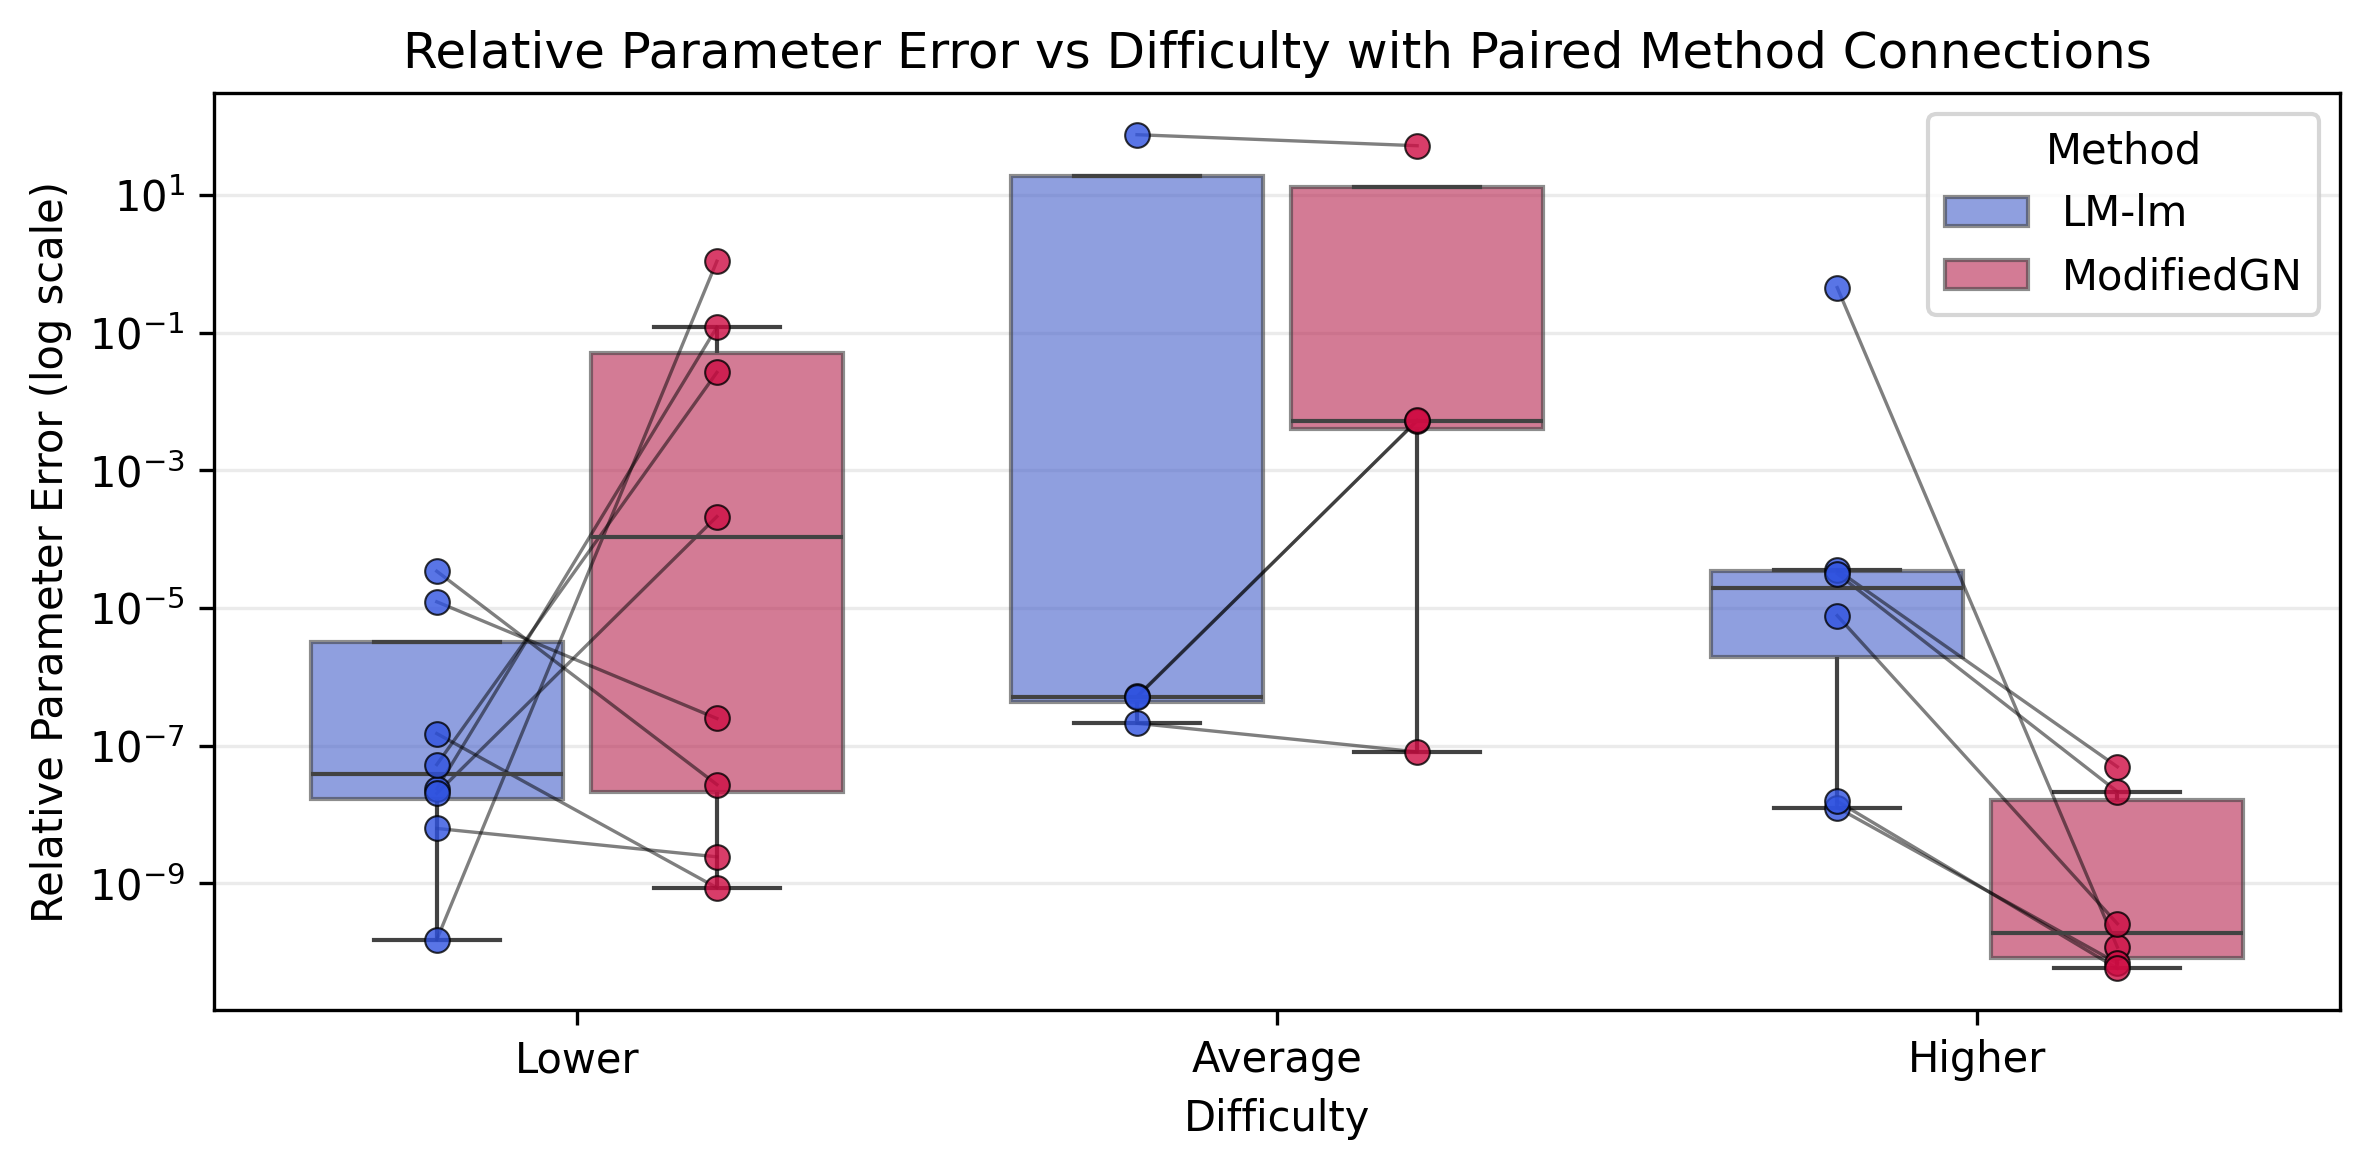

In [5]:
plot_boxplot(df_results, x="difficulty", y="relative_parameter_error",
             xlabel="Difficulty", ylabel="Relative Parameter Error",
             order=difficulty_order, palette=method_palette)

plot_boxplot_with_connections(df_results, x="difficulty", y="relative_parameter_error",
             xlabel="Difficulty", ylabel="Relative Parameter Error",
             order=difficulty_order, palette=method_palette)

In [6]:
problems_2d = [p for p in problems if p.n == 2]

/opt/anaconda3/envs/compress_explain/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_higher.py:187: RuntimeWarning: overflow encountered in multiply
  return b[0] * (1 - np.exp(-b[1] * x))
/Users/katebohan/Documents/Optimization/modified-gauss-newton/notebooks/visualization.py:319: RuntimeWarning: overflow encountered in square
  Z[i, j] = np.sum(problem.F(p)**2)


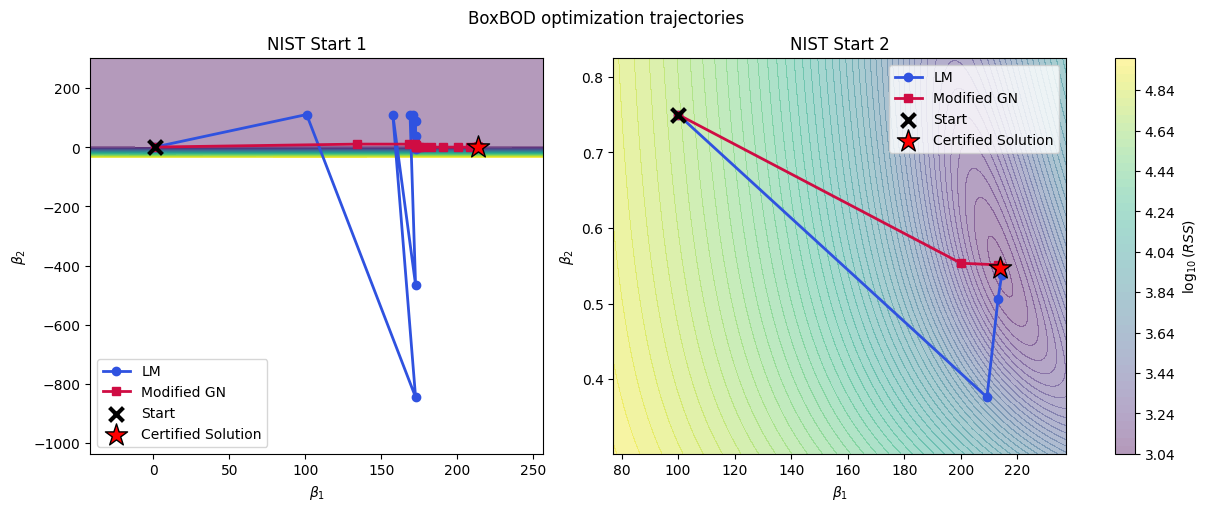

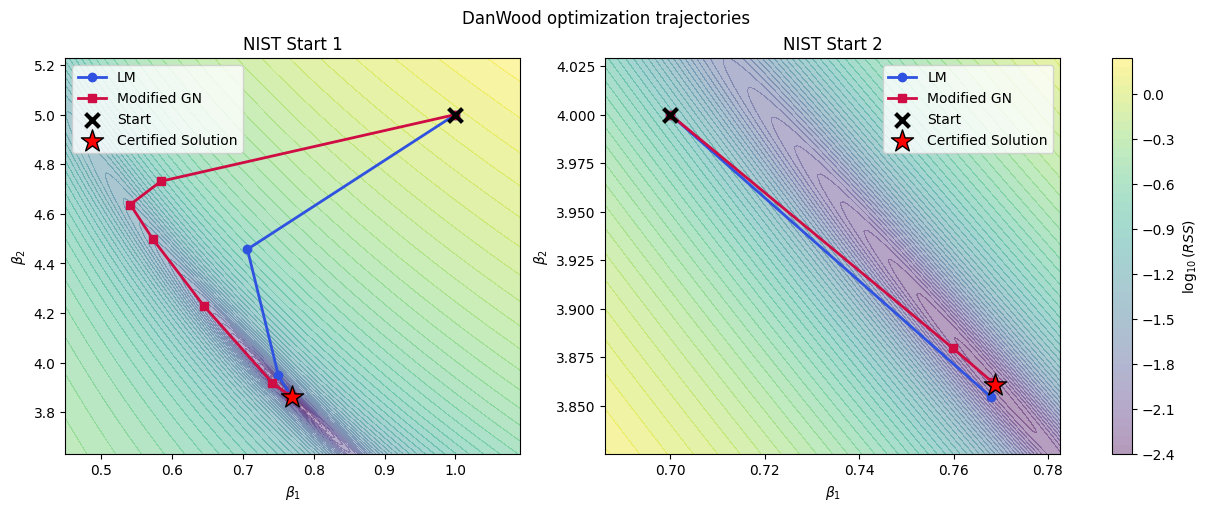

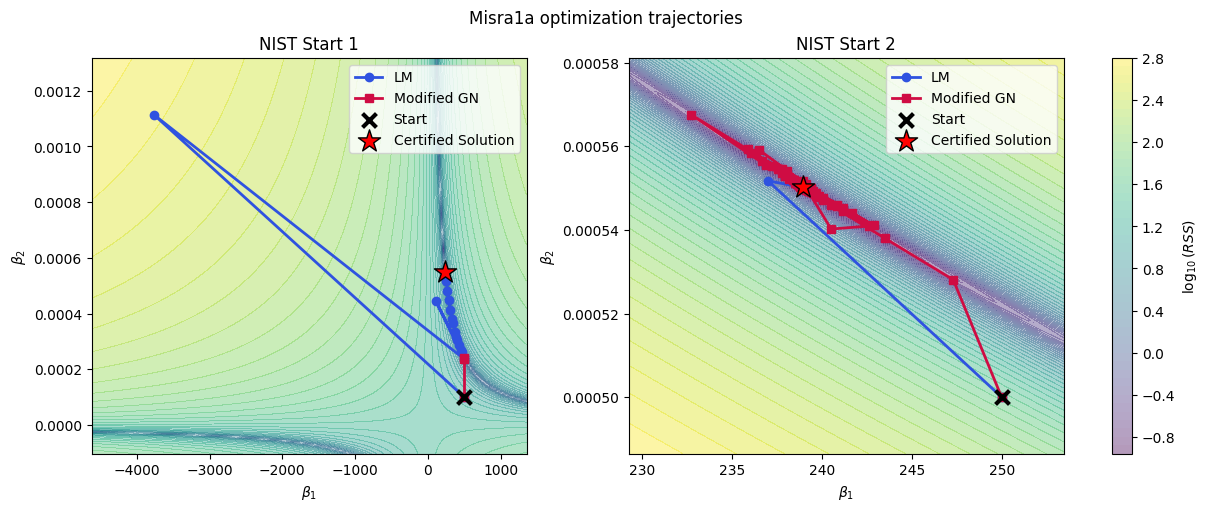

In [7]:
trajectory_data = generate_trajectory_data(
    problems_2d
)

for problem_data in trajectory_data:

    plot_optimizer_paths(problem_data)

---

In [8]:
def compare_methods_convergence(problems):

    for problem in problems:

        starts = problem.get_starting_points()
        n_starts = len(starts)

        print(f"\n=== {problem.name} ===")

        fig, axes = plt.subplots(1, n_starts, figsize=(6 * n_starts, 5), constrained_layout=True)

        if n_starts == 1:
            axes = [axes]

        for ax, (name, x0) in zip(axes, starts.items()):

            # ---------------------------------------------------
            # 1. Modified GN (Secular)
            # ---------------------------------------------------

            result_mgn = modified_gauss_newton(problem,
                x0,
                M0=1e-3,
                L0=1e-6,
                tol=1e-6,
                max_iter=100,
                subproblem_method="secular"
            )

            # TO BE DELETED
            # ---------------------------------------------------
            # 2. Modified GN (Bisection)
            # ---------------------------------------------------

            result_bis = modified_gauss_newton(
                problem,
                x0,
                M0=1e-3,
                L0=1e-6,
                tol=1e-6,
                max_iter=100,
                subproblem_method="bisection"
            )

            # ---------------------------------------------------
            # 3. SciPy LM (history safe extraction)
            # ---------------------------------------------------

            lm_res = run_lm_with_history(problem, x0)
            hist_sp = [
                np.sum(problem.F(x) ** 2)
                for x in lm_res.x_history
            ]


            ax.semilogy(result_mgn.rss_history, label="Modified GN (Secular)", linewidth=2,
                        color=method_palette["ModifiedGN"])

            ax.semilogy(result_bis.rss_history, label="Modified GN (Bisection)", linestyle="--",
                        color="black", alpha=0.7)

            ax.semilogy(hist_sp, label="SciPy LM", linewidth=2, 
                        color=method_palette["LM-lm"], alpha=0.9)

            ax.set_title(name)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("RSS")
            ax.grid(True, which="both", ls="-", alpha=0.4)
            ax.legend()

        fig.suptitle(
            f"{problem.name} – convergence comparison",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()


=== BoxBOD ===


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_57426/1546752592.py:51: RuntimeWarning: overflow encountered in square
  np.sum(problem.F(x) ** 2)
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_57426/1546752592.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


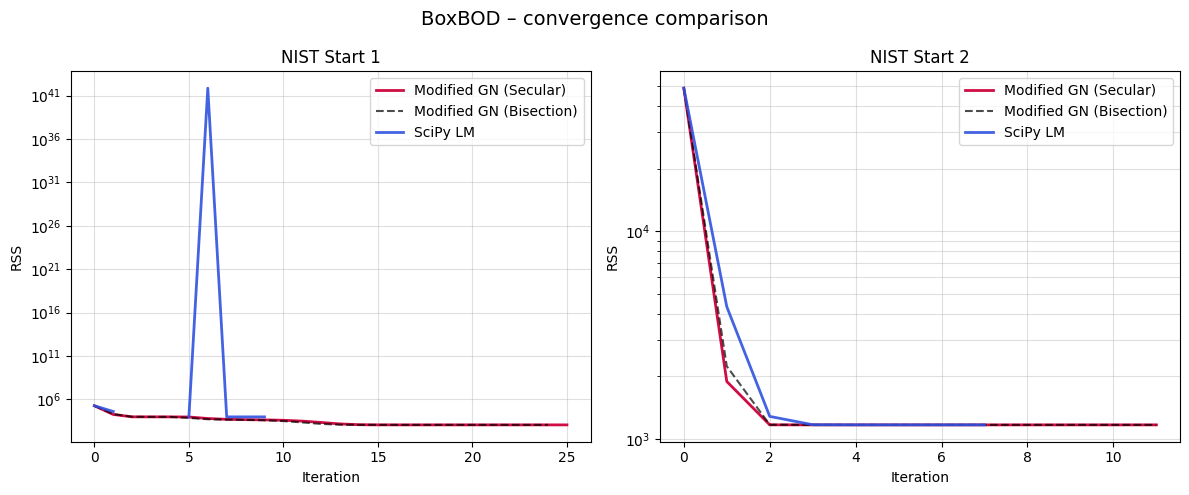


=== Chwirut1 ===


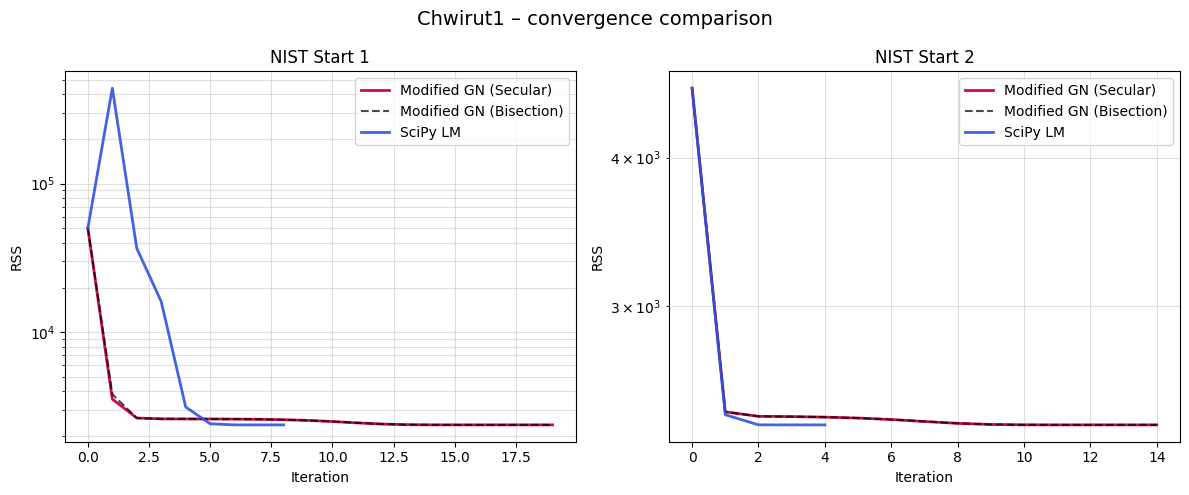


=== DanWood ===


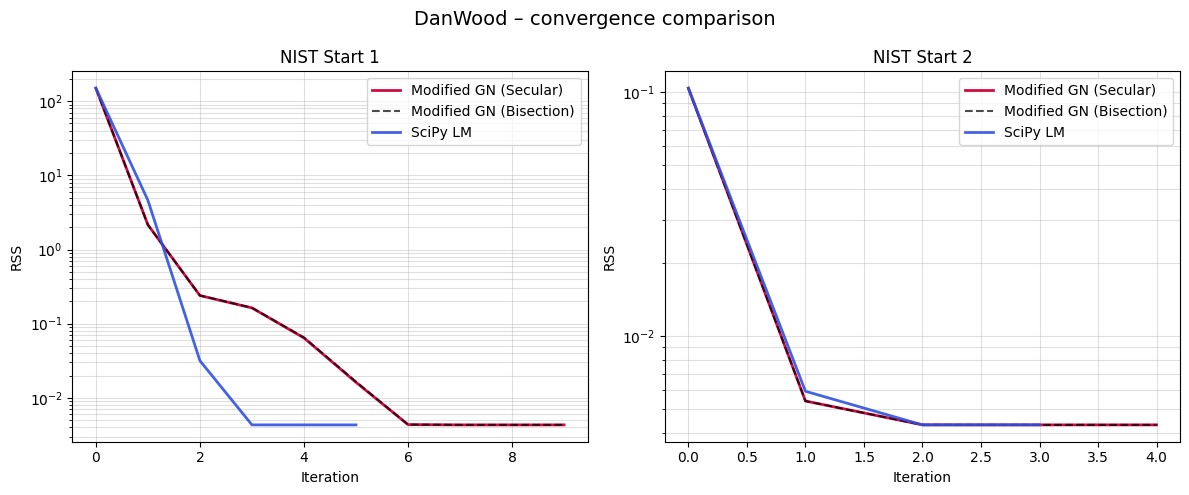


=== Eckerle4 ===


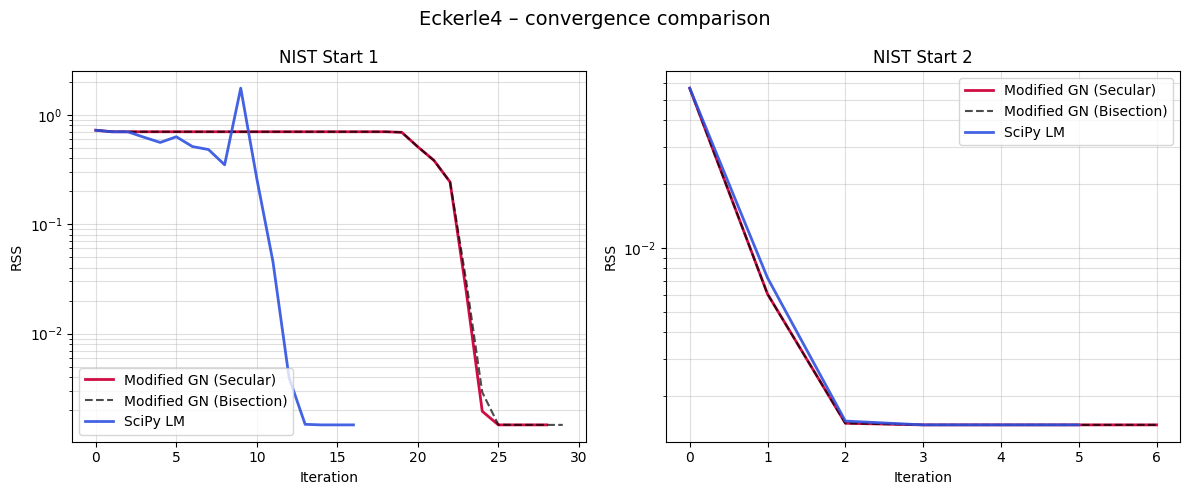


=== Lanczos3 ===


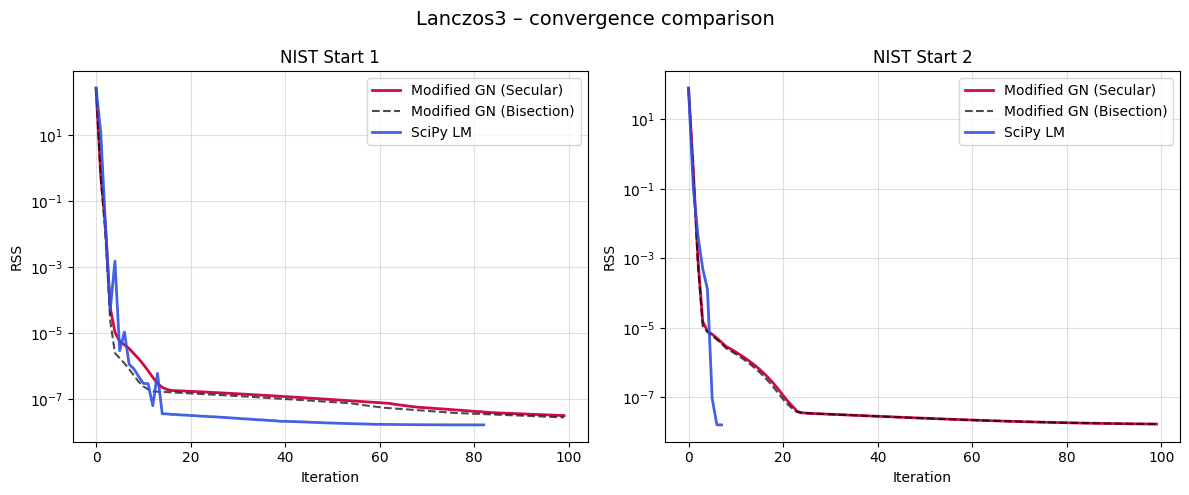


=== MGH17 ===


/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
/Users/katebohan/Documents/Optimization/modified-gauss-newton/optimization_project/problems/overdetermined/problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]


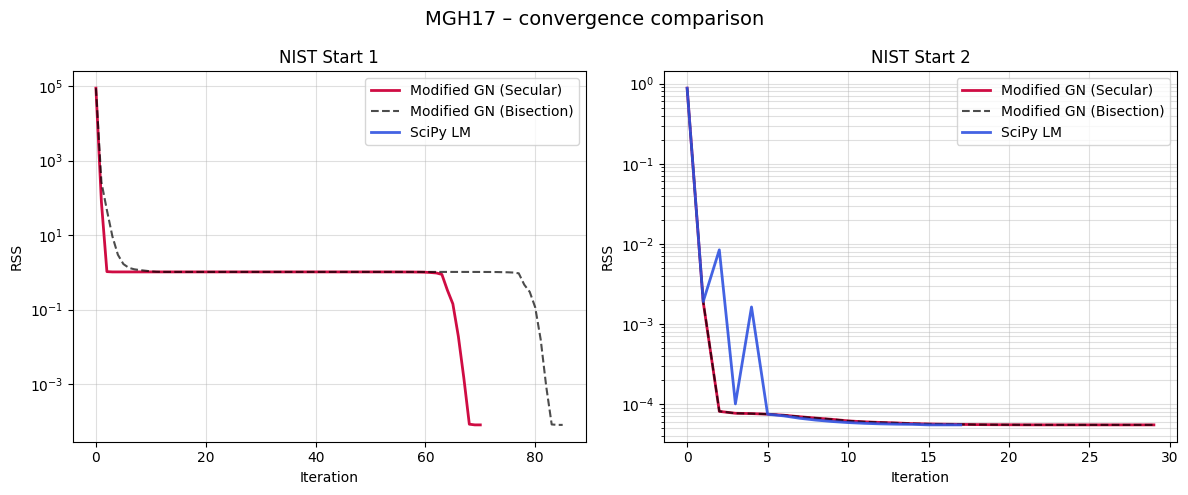


=== Misra1a ===


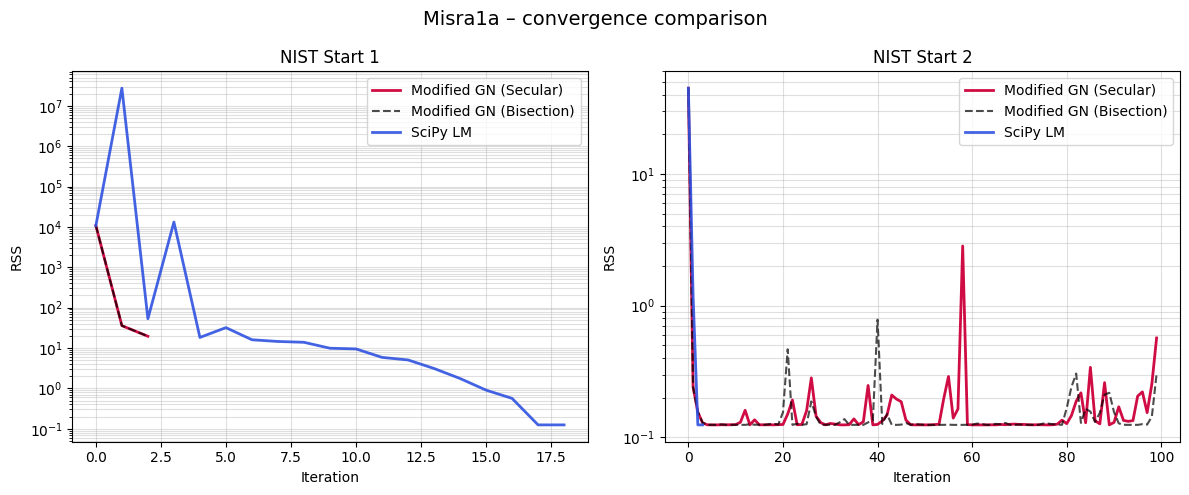


=== Roszman1 ===


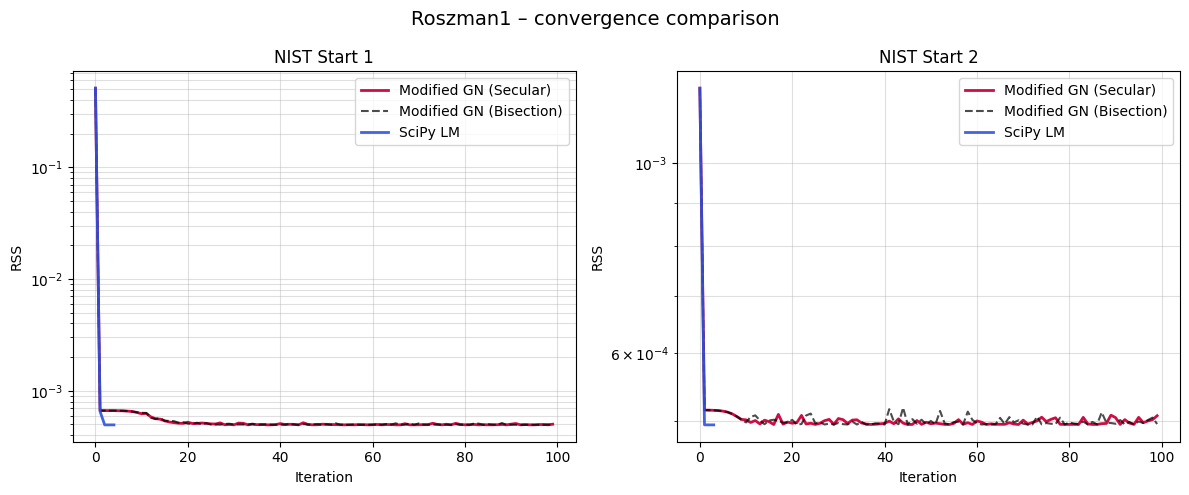


=== Thurber ===


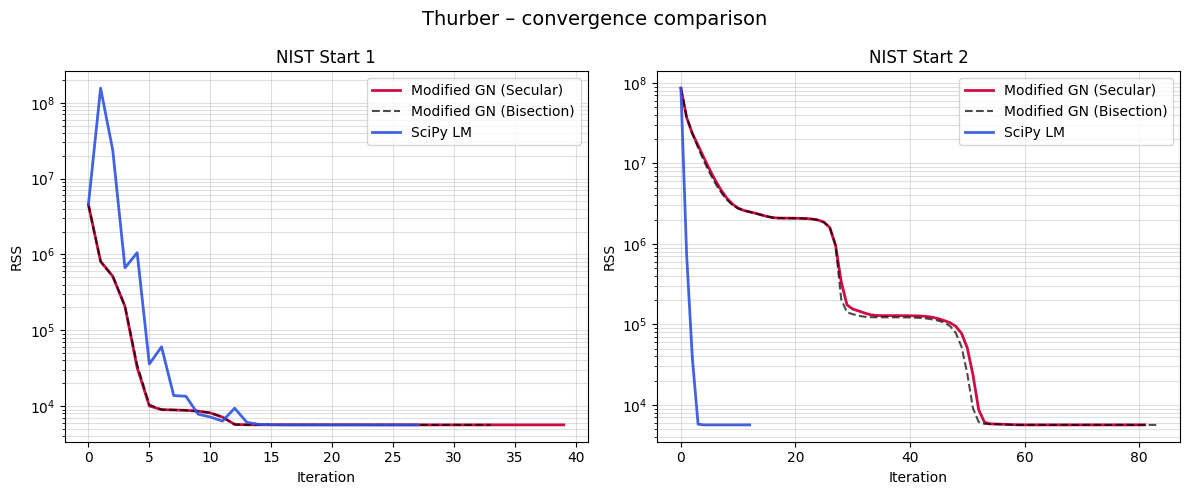

In [9]:
compare_methods_convergence(problems)